In [3]:
import pandas as pd
df = pd.read_csv("../data/FIR_Details_Data.csv")
df.head()

/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/2903311514.py:2: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/FIR_Details_Data.csv")


,District_Name,UnitName,FIR_YEAR,FIR_MONTH,Offence_Duration,FIR_Day,FIR Type,FIR_Stage,Complaint_Mode,CrimeGroup_Name,...,Girl,Age 0,VICTIM COUNT,Accused Count,Arrested Male,Arrested Female,Arrested Count\tNo.,Accused_ChargeSheeted Count,Conviction Count,Unit_ID
0,Bagalkot,Amengad PS,2016,1,0,5,Non Heinous,Dis/Acq,Written,POCSO,...,1,0,0,1,1,0,1,1,0,1245
1,Bagalkot,Amengad PS,2016,1,0,12,Non Heinous,Convicted,Sue-moto by Police,KARNATAKA POLICE ACT 1963,...,0,0,0,5,5,0,5,5,2,1245
2,Bagalkot,Amengad PS,2016,1,0,12,Non Heinous,Convicted,Sue-moto by Police,KARNATAKA POLICE ACT 1963,...,0,0,0,1,1,0,1,1,0,1245
3,Bagalkot,Amengad PS,2016,1,0,15,Non Heinous,Convicted,Written,MOTOR VEHICLE ACCIDENTS NON-FATAL,...,0,1,0,1,1,0,1,1,0,1245
4,Bagalkot,Amengad PS,2016,1,0,18,Heinous,Pending Trial,Written,MOTOR VEHICLE ACCIDENTS FATAL,...,0,0,0,1,1,0,1,1,0,1245


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1674734 entries, 0 to 1674733
Data columns (total 34 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   District_Name                1674734 non-null  object 
 1   UnitName                     1674734 non-null  object 
 2   FIR_YEAR                     1674734 non-null  int64  
 3   FIR_MONTH                    1674734 non-null  int64  
 4   Offence_Duration             1674734 non-null  int64  
 5   FIR_Day                      1674734 non-null  int64  
 6   FIR Type                     1674734 non-null  object 
 7   FIR_Stage                    1674734 non-null  object 
 8   Complaint_Mode               1674734 non-null  object 
 9   CrimeGroup_Name              1674734 non-null  object 
 10  CrimeHead_Name               1674734 non-null  object 
 11  Latitude                     508134 non-null   float64
 12  Longitude                    508099 non-nu

District_Name                        0
UnitName                             0
FIR_YEAR                             0
FIR_MONTH                            0
Offence_Duration                     0
FIR_Day                              0
FIR Type                             0
FIR_Stage                            0
Complaint_Mode                       0
CrimeGroup_Name                      0
CrimeHead_Name                       0
Latitude                       1166600
Longitude                      1166635
ActSection                           0
IOName                               0
KGID                                 0
Internal_IO                          0
Place of Offence                     0
Distance from PS                     0
Beat_Name                            0
Village_Area_Name                    0
Male                                 0
Female                               0
Boy                                  0
Girl                                 0
Age 0                    

In [5]:
df_geo = df.dropna(subset=["Latitude", "Longitude"])

print(df_geo.shape)

(508066, 34)


In [6]:
df_clean = df_geo[[
    "Latitude", "Longitude",
    "FIR_YEAR", "FIR_MONTH", "FIR_Day",
    "CrimeGroup_Name"
]]

In [7]:
df_clean["date"] = pd.to_datetime(
    df_clean["FIR_YEAR"].astype(str) + "-" +
    df_clean["FIR_MONTH"].astype(str) + "-" +
    df_clean["FIR_Day"].astype(str),
    errors="coerce"
)

/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/892486581.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["date"] = pd.to_datetime(


In [8]:
location_risk = (
    df_clean.groupby(["Latitude", "Longitude"])
    .size()
    .reset_index(name="crime_count")
)

In [9]:
location_risk["risk_score"] = (
    location_risk["crime_count"] /
    location_risk["crime_count"].max()
)

In [10]:
location_risk.describe()

,Latitude,Longitude,crime_count,risk_score
count,442960.000000,442960.000000,442960.000000,442960.000000
mean,15.100041,75.309724,1.146979,0.001443
std,8.011362,9.257398,2.891427,0.003637
min,-0.770929,0.001000,1.000000,0.001258
25%,12.960240,75.365474,1.000000,0.001258
50%,13.353357,76.632807,1.000000,0.001258
75%,15.528533,77.532745,1.000000,0.001258
max,131.429990,777.744746,795.000000,1.000000


In [11]:
location_risk.head()
location_risk.shape

(442960, 4)

In [16]:
sample = location_risk.sample(5000)

In [21]:
from folium.plugins import HeatMap

HeatMap(
    heat_data,
    radius=8,        # smaller radius
    blur=6,          # smoother blending
    max_zoom=12,
    min_opacity=0.2
).add_to(map_)

In [28]:
sample = location_risk.sample(5000)

In [29]:
import numpy as np

location_risk["risk_score_capped"] = np.clip(
    location_risk["risk_score"], 0, 0.7
)

In [30]:
sample = location_risk.iloc[::50]   # take every 50th point

In [31]:
heat_data = sample[["Latitude", "Longitude", "risk_score_capped"]].values.tolist()

In [32]:
HeatMap(
    heat_data,
    radius=8,
    blur=6,
    gradient={
        0.2: "blue",
        0.4: "lime",
        0.6: "yellow",
        0.8: "orange",
        1.0: "red"
    }
).add_to(map_)

In [35]:
from folium.plugins import MarkerCluster

cluster = MarkerCluster().add_to(map_)

for _, row in sample.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]]
    ).add_to(cluster)

In [36]:
map_.save("map.html")

In [43]:
df_blr = df_clean[
    (df_clean["Latitude"] >= 12.8) & (df_clean["Latitude"] <= 13.2) &
    (df_clean["Longitude"] >= 77.4) & (df_clean["Longitude"] <= 77.8)
]

In [44]:
df_blr["lat_bin"] = df_blr["Latitude"].round(3)
df_blr["lon_bin"] = df_blr["Longitude"].round(3)

/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/3044610906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["lat_bin"] = df_blr["Latitude"].round(3)
/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/3044610906.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["lon_bin"] = df_blr["Longitude"].round(3)


In [45]:
grid_risk = (
    df_blr.groupby(["lat_bin", "lon_bin"])
    .size()
    .reset_index(name="crime_count")
)

grid_risk["risk_score"] = (
    grid_risk["crime_count"] / grid_risk["crime_count"].max()
)

In [47]:
map_ = folium.Map(location=[12.97, 77.59], zoom_start=12)

In [48]:
heat_data = grid_risk[["lat_bin", "lon_bin", "risk_score"]].values.tolist()

HeatMap(
    heat_data,
    radius=10,
    blur=8,
    min_opacity=0.3
).add_to(map_)

In [52]:
df_blr["lat_bin"] = df_blr["Latitude"].round(3)
df_blr["lon_bin"] = df_blr["Longitude"].round(3)

/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/3044610906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["lat_bin"] = df_blr["Latitude"].round(3)
/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/3044610906.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["lon_bin"] = df_blr["Longitude"].round(3)


In [53]:
grid = (
    df_blr.groupby(["lat_bin", "lon_bin"])
    .size()
    .reset_index(name="crime_count")
)

In [54]:
grid["crime_density"] = (
    grid["crime_count"] / grid["crime_count"].sum()
)

In [55]:
top_zones = grid.sort_values("crime_count", ascending=False).head(20)

Matplotlib is building the font cache; this may take a moment.


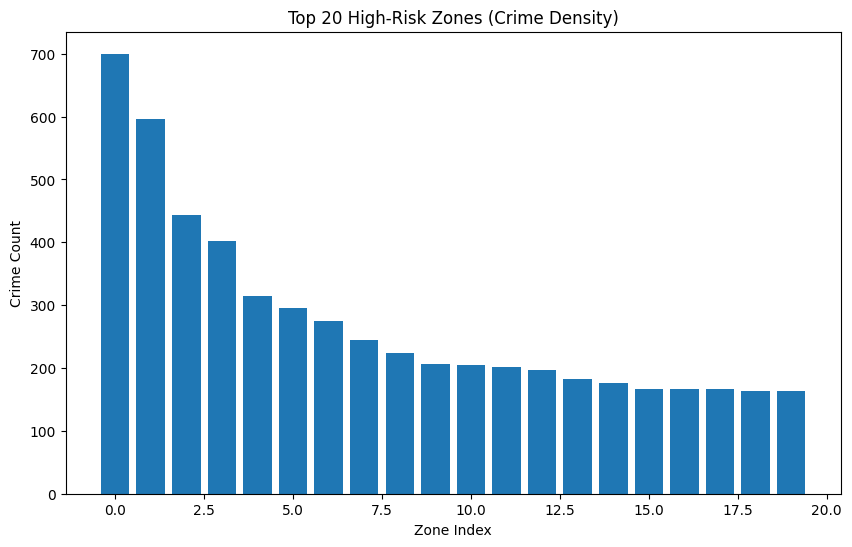

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(range(len(top_zones)), top_zones["crime_count"])

plt.title("Top 20 High-Risk Zones (Crime Density)")
plt.xlabel("Zone Index")
plt.ylabel("Crime Count")

plt.show()

In [58]:
import datetime

hour = datetime.datetime.now().hour

def time_risk(hour):
    if 20 <= hour or hour <= 5:
        return 1.5
    elif 6 <= hour <= 10:
        return 1.2
    else:
        return 1.0

grid["live_risk"] = grid["crime_density"] * time_risk(hour)

In [59]:
import folium

map_ = folium.Map(location=[12.97, 77.59], zoom_start=12)

heat_data = grid[["lat_bin", "lon_bin", "live_risk"]].values.tolist()

from folium.plugins import HeatMap

HeatMap(heat_data).add_to(map_)

In [62]:
grid["risk_score"] = np.log1p(grid["crime_count"])
grid["risk_score"] = grid["risk_score"] / grid["risk_score"].max()

In [63]:
grid_filtered = grid[grid["crime_count"] > 5]

In [64]:
grid_filtered["risk_score"] = np.clip(
    grid_filtered["risk_score"], 0, 0.8
)

/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/2805152847.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_filtered["risk_score"] = np.clip(


In [65]:
heat_data = grid_filtered[["lat_bin", "lon_bin", "risk_score"]].values.tolist()

HeatMap(
    heat_data,
    radius=12,
    blur=10,
    min_opacity=0.2
).add_to(map_)

In [75]:
df_clean = df_geo[[
    "Latitude", "Longitude",
    "FIR_YEAR", "FIR_MONTH", "FIR_Day",
    "CrimeGroup_Name",
    "Female", "Girl"
]]

In [ ]:
df_blr = df_clean[
    (df_clean["Latitude"] >= 12.8) & (df_clean["Latitude"] <= 13.2) &
    (df_clean["Longitude"] >= 77.4) & (df_clean["Longitude"] <= 77.8)
].copy()

In [94]:
grid_size = 0.003

import numpy as np

df_blr["lat_bin"] = np.floor(df_blr["Latitude"] / grid_size) * grid_size
df_blr["lon_bin"] = np.floor(df_blr["Longitude"] / grid_size) * grid_size

/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/940987034.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["lat_bin"] = np.floor(df_blr["Latitude"] / grid_size) * grid_size
/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/940987034.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["lon_bin"] = np.floor(df_blr["Longitude"] / grid_size) * grid_size


In [95]:
print(df_blr.columns)

Index(['Latitude', 'Longitude', 'FIR_YEAR', 'FIR_MONTH', 'FIR_Day',
       'CrimeGroup_Name', 'Female', 'Girl', 'lat_bin', 'lon_bin'],
      dtype='object')


In [96]:
grid = (
    df_blr.groupby(["lat_bin", "lon_bin"])
    .agg({
        "CrimeGroup_Name": "count",
        "Female": "sum",
        "Girl": "sum"
    })
    .reset_index()
)

grid.rename(columns={"CrimeGroup_Name": "crime_count"}, inplace=True)

In [97]:
grid["women_risk"] = grid["Female"] + grid["Girl"]

grid["risk_score"] = (
    0.7 * grid["crime_count"] +
    0.3 * grid["women_risk"]
)

In [98]:
import numpy as np

grid["risk_score"] = np.log1p(grid["risk_score"])
grid["risk_score"] = grid["risk_score"] / grid["risk_score"].max()

In [99]:
def risk_level(score):
    if score > 0.7:
        return "high"
    elif score > 0.4:
        return "medium"
    else:
        return "low"

grid["risk_level"] = grid["risk_score"].apply(risk_level)

In [100]:
import folium

map_ = folium.Map(location=[12.97, 77.59], zoom_start=14)

for _, row in grid.iterrows():
    
    if row["risk_level"] == "high":
        color = "#ff4d4d"   # red
    elif row["risk_level"] == "medium":
        color = "#ffa64d"   # orange
    else:
        color = "#66cc66"   # green

    folium.Rectangle(
        bounds=[
            [row["lat_bin"], row["lon_bin"]],
            [row["lat_bin"] + grid_size, row["lon_bin"] + grid_size]
        ],
        fill=True,
        fill_color=color,
        fill_opacity=0.4,
        color=None
    ).add_to(map_)

In [101]:
for _, row in grid.iterrows():

    tooltip_text = f"""
    Risk Level: {row['risk_level']}<br>
    Crimes: {row['crime_count']}<br>
    Women Affected: {row['Female'] + row['Girl']}
    """

    folium.Rectangle(
        bounds=[
            [row["lat_bin"], row["lon_bin"]],
            [row["lat_bin"] + grid_size, row["lon_bin"] + grid_size]
        ],
        fill=True,
        fill_color=color,
        fill_opacity=0.4,
        tooltip=tooltip_text
    ).add_to(map_)

In [102]:
legend_html = """
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 150px; height: 120px; 
     background-color: white; z-index:9999; padding:10px;
     border:2px solid grey;">
<b>Risk Levels</b><br>
<span style="color:#ff4d4d;">■</span> High<br>
<span style="color:#ffa64d;">■</span> Medium<br>
<span style="color:#66cc66;">■</span> Low
</div>
"""

map_.get_root().html.add_child(folium.Element(legend_html))

In [104]:
grid_size = 0.01   # ~1 km

In [105]:
df_blr["lat_bin"] = np.floor(df_blr["Latitude"] / grid_size) * grid_size
df_blr["lon_bin"] = np.floor(df_blr["Longitude"] / grid_size) * grid_size

/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/3060080552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["lat_bin"] = np.floor(df_blr["Latitude"] / grid_size) * grid_size
/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/3060080552.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["lon_bin"] = np.floor(df_blr["Longitude"] / grid_size) * grid_size


In [106]:
df_blr["date"] = pd.to_datetime(
    df_blr["FIR_YEAR"].astype(str) + "-" +
    df_blr["FIR_MONTH"].astype(str) + "-" +
    df_blr["FIR_Day"].astype(str)
)

df_blr["hour"] = df_blr["date"].dt.hour
df_blr["day_of_week"] = df_blr["date"].dt.dayofweek

/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/1313431080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["date"] = pd.to_datetime(
/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/1313431080.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_blr["hour"] = df_blr["date"].dt.hour
/var/folders/kt/g4cyrd2x71178_88qd67cdn40000gp/T/ipykernel_76303/1313431080.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [ ]:
ml_data = (
    df_blr.groupby(["lat_bin", "lon_bin", "day_of_week"])
    .size()
    .reset_index(name="crime_count")
)

In [108]:
from sklearn.ensemble import RandomForestRegressor

X = ml_data[["lat_bin", "lon_bin", "day_of_week"]]
y = ml_data["crime_count"]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [109]:
ml_data["predicted_risk"] = model.predict(X)

# normalize
ml_data["predicted_risk"] = (
    ml_data["predicted_risk"] / ml_data["predicted_risk"].max()
)

In [115]:
import streamlit as st

mode = st.radio("Select Mode", ["Historical", "Predicted"])


2026-05-02 20:31:30.044 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 20:31:30.046 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 20:31:30.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 20:31:30.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 20:31:30.049 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 20:31:30.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 20:31:30.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [118]:
pred_grid = (
    ml_data.groupby(["lat_bin", "lon_bin"])["predicted_risk"]
    .mean()
    .reset_index()
)

In [119]:
grid = grid.merge(pred_grid, on=["lat_bin", "lon_bin"], how="left")
grid["predicted_risk"] = grid["predicted_risk"].fillna(0)

In [120]:
grid["historical_risk"] = grid["risk_score"]

In [121]:
if mode == "Predicted":
    grid["risk_score"] = grid["predicted_risk"]
else:
    grid["risk_score"] = grid["historical_risk"]

In [122]:
def risk_level(score):
    if score > 0.7:
        return "high"
    elif score > 0.4:
        return "medium"
    else:
        return "low"

grid["risk_level"] = grid["risk_score"].apply(risk_level)

In [123]:
import folium

map_ = folium.Map(location=[12.97, 77.59], zoom_start=13)

for _, row in grid.iterrows():

    if row["risk_level"] == "high":
        color = "#ff4d4d"
    elif row["risk_level"] == "medium":
        color = "#ffa64d"
    else:
        color = "#66cc66"

    folium.Rectangle(
        bounds=[
            [row["lat_bin"], row["lon_bin"]],
            [row["lat_bin"] + grid_size, row["lon_bin"] + grid_size]
        ],
        fill=True,
        fill_color=color,
        fill_opacity=0.4,
        color=None,
        tooltip=f"""
        Mode: {mode}<br>
        Risk: {row['risk_score']:.2f}<br>
        Crimes: {row['crime_count']}
        """
    ).add_to(map_)

In [125]:
map_.save("map.html")